This notebook builds a credit risk scoring pipeline using the Give Me Some Credit dataset. The objective is to predict whether a borrower will experience serious financial distress within the next two years.

The workflow covers:
- Data preprocessing and leakage-safe train/validation split
- Missing-value treatment and outlier capping
- WOE binning and credit-risk feature engineering
- Model comparison across Logistic Regression, XGBoost, and LightGBM
- Evaluation using AUC-ROC, F1-score, and Recall
- Model interpretability using SHAP

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scorecardpy as sc
import lightgbm as lgb
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

# 1. Preprocessing
- Imputation
- Outliers handling
- Feature selection

In [5]:
# =========================
# Load data
# =========================
df = pd.read_csv("/kaggle/input/GiveMeSomeCredit/cs-training.csv", index_col=0)

target = "SeriousDlqin2yrs"

X = df.drop(columns=[target])
y = df[target]

# =========================
# 0. Train / valid split FIRST
# =========================
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 1. Remove variables with missing > 30%
# =========================
missing_rate_train = X_train_raw.isnull().mean()

cols_keep = missing_rate_train[missing_rate_train <= 0.30].index.tolist()

X_train_fs = X_train_raw[cols_keep].copy()
X_valid_fs = X_valid_raw[cols_keep].copy()

print("Removed due to missing > 30%:")
print(missing_rate_train[missing_rate_train > 0.30])

# =========================
# 2. Outlier capping at 99th percentile
# =========================
p99_train = X_train_fs.quantile(0.99)

X_train_cap = X_train_fs.copy()
X_valid_cap = X_valid_fs.copy()

for col in cols_keep:
    X_train_cap[col] = X_train_cap[col].clip(upper=p99_train[col])
    X_valid_cap[col] = X_valid_cap[col].clip(upper=p99_train[col])

# =========================
# 3. Impute missing values with median
# =========================
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_cap),
    columns=X_train_cap.columns,
    index=X_train_cap.index
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid_cap),
    columns=X_valid_cap.columns,
    index=X_valid_cap.index
)

# =========================
# 4. Remove variables with VIF > 10
# =========================
def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_df


X_train_vif = X_train_imp.copy()
removed_vif_features = []

while True:
    vif_df = calculate_vif(X_train_vif)
    max_vif = vif_df["VIF"].max()

    if max_vif <= 10:
        break

    feature_to_remove = (
        vif_df
        .sort_values("VIF", ascending=False)
        .iloc[0]["feature"]
    )

    removed_vif_features.append(feature_to_remove)
    X_train_vif = X_train_vif.drop(columns=[feature_to_remove])

selected_vif_features = X_train_vif.columns.tolist()

X_train_final = X_train_imp[selected_vif_features].copy()
X_valid_final = X_valid_imp[selected_vif_features].copy()

print("Removed due to VIF > 10:")
print(removed_vif_features)

# =========================
# 5. WOE binning
# =========================
train_for_woe = pd.concat(
    [X_train_final, y_train.rename(target)],
    axis=1
)

valid_for_woe = pd.concat(
    [X_valid_final, y_valid.rename(target)],
    axis=1
)

bins = sc.woebin(
    train_for_woe,
    y=target,
    bin_num_limit=5
)

train_woe = sc.woebin_ply(train_for_woe, bins)
valid_woe = sc.woebin_ply(valid_for_woe, bins)

X_train_woe = train_woe.filter(regex="_woe$")
X_valid_woe = valid_woe.filter(regex="_woe$")

y_train_final = train_woe[target]
y_valid_final = valid_woe[target]

# =========================
# 6. LightGBM Dataset
# =========================
dtrain = lgb.Dataset(X_train_woe, label=y_train_final)
dvalid = lgb.Dataset(X_valid_woe, label=y_valid_final, reference=dtrain)

Removed due to missing > 30%:
Series([], dtype: float64)


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


Removed due to VIF > 10:
[]
[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


# 2. Model training & Evaluation
- Model: LR, XGBoost, LightGBM
- Evaluation: AUC, F1-score, Recall

In [6]:
# =========================
# Class imbalance ratio
# =========================
ratio = y_train_final.value_counts()[0] / y_train_final.value_counts()[1]

results = []
models = {}

model_feature_cols = X_train_woe.columns.tolist()

# =========================
# Helper function
# =========================
def evaluate_model(model_name, y_true, y_score, threshold=0.5):
    auc = roc_auc_score(y_true, y_score)

    if model_name == "SVM":
        y_pred = (y_score >= 0).astype(int)
    else:
        y_pred = (y_score >= threshold).astype(int)

    f1 = f1_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    return {
        "Model": model_name,
        "AUC": auc,
        "F1-score": f1,
        "Recall": recall
    }


# =========================================================
# 1. Logistic Regression + Hyperopt
# =========================================================
lr_space = {
    "C": hp.loguniform("lr_C", np.log(1e-4), np.log(100)),
    "penalty": hp.choice("lr_penalty", ["l2"]),
    "solver": hp.choice("lr_solver", ["lbfgs", "liblinear"])
}

def lr_objective(params):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=params["C"],
            penalty=params["penalty"],
            solver=params["solver"],
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    model.fit(X_train_woe, y_train_final)
    y_pred = model.predict_proba(X_valid_woe)[:, 1]
    auc = roc_auc_score(y_valid_final, y_pred)

    return {
        "loss": -auc,
        "status": STATUS_OK,
        "model": model
    }

lr_trials = Trials()

best_lr = fmin(
    fn=lr_objective,
    space=lr_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=lr_trials,
    rstate=np.random.default_rng(42)
)

best_lr_trial = sorted(lr_trials.results, key=lambda x: x["loss"])[0]
lr_model = best_lr_trial["model"]

lr_val_pred = lr_model.predict_proba(X_valid_woe)[:, 1]

results.append(
    evaluate_model(
        model_name="Logistic Regression",
        y_true=y_valid_final,
        y_score=lr_val_pred
    )
)

models["Logistic Regression"] = lr_model


# =========================================================
# 2. XGBoost + Hyperopt
# =========================================================
dtrain_xgb = xgb.DMatrix(X_train_woe, label=y_train_final)
dvalid_xgb = xgb.DMatrix(X_valid_woe, label=y_valid_final)

xgb_space = {
    "eta": hp.loguniform("xgb_eta", np.log(0.005), np.log(0.1)),
    "max_depth": hp.choice("xgb_max_depth", [2, 3, 4, 5, 6]),
    "min_child_weight": hp.loguniform("xgb_min_child_weight", np.log(1), np.log(20)),
    "subsample": hp.uniform("xgb_subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("xgb_colsample_bytree", 0.6, 1.0),
    "gamma": hp.uniform("xgb_gamma", 0, 5),
    "lambda": hp.loguniform("xgb_lambda", np.log(1e-3), np.log(100)),
    "alpha": hp.loguniform("xgb_alpha", np.log(1e-3), np.log(100))
}

def xgb_objective(params):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "eta": params["eta"],
        "max_depth": int(params["max_depth"]),
        "min_child_weight": params["min_child_weight"],
        "subsample": params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "gamma": params["gamma"],
        "lambda": params["lambda"],
        "alpha": params["alpha"],
        "scale_pos_weight": ratio,
        "seed": 42,
        "verbosity": 0
    }

    model = xgb.train(
        params=params,
        dtrain=dtrain_xgb,
        num_boost_round=2000,
        evals=[(dvalid_xgb, "valid")],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred = model.predict(
        dvalid_xgb,
        iteration_range=(0, model.best_iteration + 1)
    )

    auc = roc_auc_score(y_valid_final, y_pred)

    return {
        "loss": -auc,
        "status": STATUS_OK,
        "model": model,
        "best_iteration": model.best_iteration
    }

xgb_trials = Trials()

best_xgb = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=xgb_trials,
    rstate=np.random.default_rng(42)
)

best_xgb_trial = sorted(xgb_trials.results, key=lambda x: x["loss"])[0]
xgb_model = best_xgb_trial["model"]

xgb_val_pred = xgb_model.predict(
    dvalid_xgb,
    iteration_range=(0, xgb_model.best_iteration + 1)
)

results.append(
    evaluate_model(
        model_name="XGBoost",
        y_true=y_valid_final,
        y_score=xgb_val_pred
    )
)

models["XGBoost"] = xgb_model


# =========================================================
# 3. LightGBM + Hyperopt
# =========================================================
lgb_space = {
    "learning_rate": hp.loguniform("lgb_learning_rate", np.log(0.005), np.log(0.1)),
    "num_leaves": hp.choice("lgb_num_leaves", [7, 15, 31, 63, 127]),
    "max_depth": hp.choice("lgb_max_depth", [-1, 3, 4, 5, 6, 8]),
    "min_child_samples": hp.choice("lgb_min_child_samples", [10, 20, 30, 50, 100]),
    "subsample": hp.uniform("lgb_subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("lgb_colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.loguniform("lgb_reg_alpha", np.log(1e-3), np.log(100)),
    "reg_lambda": hp.loguniform("lgb_reg_lambda", np.log(1e-3), np.log(100))
}

def lgb_objective(params):
    lgb_params = {
        "boosting_type": "gbdt",
        "objective": "binary",
        "metric": "auc",

        "learning_rate": params["learning_rate"],
        "num_leaves": int(params["num_leaves"]),
        "max_depth": int(params["max_depth"]),
        "min_child_samples": int(params["min_child_samples"]),

        "subsample": params["subsample"],
        "subsample_freq": 1,
        "colsample_bytree": params["colsample_bytree"],

        "reg_alpha": params["reg_alpha"],
        "reg_lambda": params["reg_lambda"],

        "scale_pos_weight": ratio,
        "feature_pre_filter": False,

        "verbose": -1,
        "seed": 42
    }

    lgb_train_trial = lgb.Dataset(
        X_train_woe,
        label=y_train_final,
        free_raw_data=False
    )

    lgb_valid_trial = lgb.Dataset(
        X_valid_woe,
        label=y_valid_final,
        reference=lgb_train_trial,
        free_raw_data=False
    )

    model = lgb.train(
        lgb_params,
        lgb_train_trial,
        num_boost_round=2000,
        valid_sets=[lgb_valid_trial],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )

    y_pred = model.predict(
        X_valid_woe,
        num_iteration=model.best_iteration
    )

    auc = roc_auc_score(y_valid_final, y_pred)

    return {
        "loss": -auc,
        "status": STATUS_OK,
        "model": model,
        "best_iteration": model.best_iteration,
        "params": lgb_params
    }

lgb_trials = Trials()

best_lgb = fmin(
    fn=lgb_objective,
    space=lgb_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=lgb_trials,
    rstate=np.random.default_rng(42)
)

best_lgb_trial = sorted(lgb_trials.results, key=lambda x: x["loss"])[0]
lgb_model = best_lgb_trial["model"]

lgb_val_pred = lgb_model.predict(
    X_valid_woe,
    num_iteration=lgb_model.best_iteration
)

results.append(
    evaluate_model(
        model_name="LightGBM",
        y_true=y_valid_final,
        y_score=lgb_val_pred
    )
)

models["LightGBM"] = lgb_model

# =========================
# Compare models
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("AUC", ascending=False).reset_index(drop=True)

print("\nEvaluation results:")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("\nBest model by validation AUC:", best_model_name)

100%|██████████| 30/30 [01:42<00:00,  3.42s/trial, best loss: -0.8631890447127402]

Evaluation results:
                 Model       AUC  F1-score    Recall
0             LightGBM  0.863189  0.328759  0.788529
1              XGBoost  0.862993  0.329778  0.786534
2  Logistic Regression  0.860437  0.327624  0.787032

Best model by validation AUC: LightGBM


In [7]:
df_test = pd.read_csv("/kaggle/input/GiveMeSomeCredit/cs-test.csv", index_col=0)

X_test_raw = df_test.drop(columns=[target], errors="ignore")

X_test_fs = X_test_raw.reindex(columns=cols_keep)

X_test_cap = X_test_fs.copy()

for col in cols_keep:
    X_test_cap[col] = X_test_cap[col].clip(upper=p99_train[col])

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_cap),
    columns=X_test_cap.columns,
    index=X_test_cap.index
)

X_test_final = X_test_imp[selected_vif_features].copy()

test_woe = sc.woebin_ply(X_test_final, bins)

X_submit = test_woe.filter(regex="_woe$")

X_submit = X_submit.reindex(columns=model_feature_cols, fill_value=0)

y_submit_pred = lgb_model.predict(
    X_submit,
    num_iteration=lgb_model.best_iteration
)

submission = pd.DataFrame({
    "Id": X_submit.index,
    "Probability": y_submit_pred
})

submission.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(submission.head())
print(submission.shape)

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


[INFO] converting into woe values ...
Saved submission.csv
   Id  Probability
0   1     0.586418
1   2     0.426647
2   3     0.139034
3   4     0.567962
4   5     0.639871
(101503, 2)


# 3. Model explainability

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgb_model)

X_sample = X_valid_woe.iloc[20:30]

shap_vals = explainer.shap_values(X_sample)

if isinstance(shap_vals, list):
    shap_pos = shap_vals[1]
    expected_value = explainer.expected_value[1]
else:
    shap_pos = shap_vals
    expected_value = explainer.expected_value

for i, idx in enumerate(X_sample.index):
    print(f"Sample index: {idx}")
    for feat, val in zip(X_sample.columns, shap_pos[i]):
        print(f"  {feat}: {val:.4f}")
    print()

for i in range(len(X_sample)):
    shap.force_plot(
        expected_value,
        shap_pos[i],
        X_sample.iloc[i],
        matplotlib=True,
        show=False
    )
    plt.show()

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


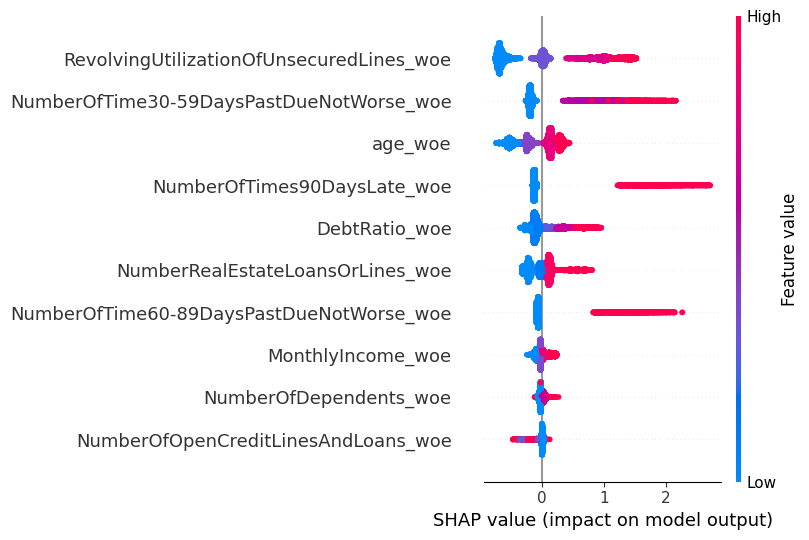

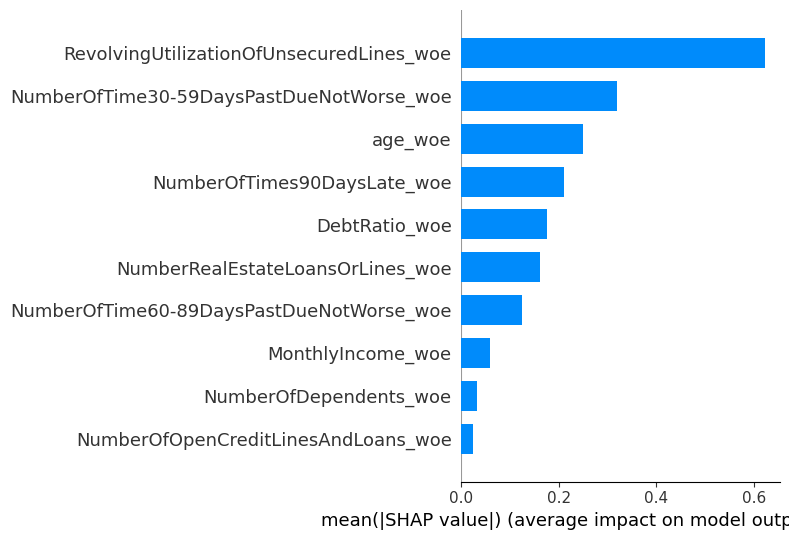

                                    feature  importance
0  RevolvingUtilizationOfUnsecuredLines_woe    0.622887
1  NumberOfTime30-59DaysPastDueNotWorse_woe    0.319627
9                                   age_woe    0.250351
3               NumberOfTimes90DaysLate_woe    0.211451
5                             DebtRatio_woe    0.175593
4          NumberRealEstateLoansOrLines_woe    0.160908
8  NumberOfTime60-89DaysPastDueNotWorse_woe    0.123836
2                         MonthlyIncome_woe    0.058872
7                    NumberOfDependents_woe    0.030892
6       NumberOfOpenCreditLinesAndLoans_woe    0.023328


In [12]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgb_model)

shap_vals = explainer.shap_values(X_valid_woe)

if isinstance(shap_vals, list):
    shap_pos = shap_vals[1]
else:
    shap_pos = shap_vals

shap.summary_plot(
    shap_pos,
    X_valid_woe
)

shap.summary_plot(
    shap_pos,
    X_valid_woe,
    plot_type="bar"
)

shap_importance = pd.DataFrame({
    "feature": X_valid_woe.columns,
    "importance": np.abs(shap_pos).mean(axis=0)
}).sort_values("importance", ascending=False)

print(shap_importance)